# Tesla Time Series Analysis 

This notebook follows the Box–Jenkins framework.

1. Identification through EDA and stationarity checks
2. Estimation through ARIMA model selection and fitting
3. Diagnostic checking through residual analysis and white noise tests


## 1. Introduction

This project analyses Tesla stock prices using time series methods. The aim is to test whether past price information has useful forecasting value.

The workflow includes decomposition, stationarity testing, ARIMA modelling, residual diagnostics, and forecast evaluation against a persistence benchmark. The final results are interpreted in the context of financial time series behaviour.

## 2. Imports

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import itertools

from sklearn.metrics import mean_squared_error, mean_absolute_error
import yfinance as yf

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from pandas.plotting import lag_plot


## 3. Data Collection and Cleaning

Download Tesla stock prices and align the series to business days.

In [48]:
data = yf.download("TSLA", start="2015-01-01", end="2026-01-01")

close = data["Close"].copy()
close.index = pd.to_datetime(close.index)

close_b = close.asfreq("B").ffill()

print(close_b.head())


[*********************100%***********************]  1 of 1 completed


Ticker           TSLA
Date                 
2015-01-02  14.620667
2015-01-05  14.006000
2015-01-06  14.085333
2015-01-07  14.063333
2015-01-08  14.041333


### Interpretation

The dataset contains daily Tesla closing prices from Yahoo Finance. The sample runs from 2015 to 2026 and exceeds the project requirement.

The date index is converted to datetime format. The series is aligned to business days and missing business day values are forward filled. This creates a regular index for decomposition testing and forecasting.

The main variable is the closing price. Log prices and log returns are derived for analysis. Prices are kept for interpretation. Returns are used for modelling because they are more likely to be stationary.

## 4. Line Plot

Shows trend and volatility.

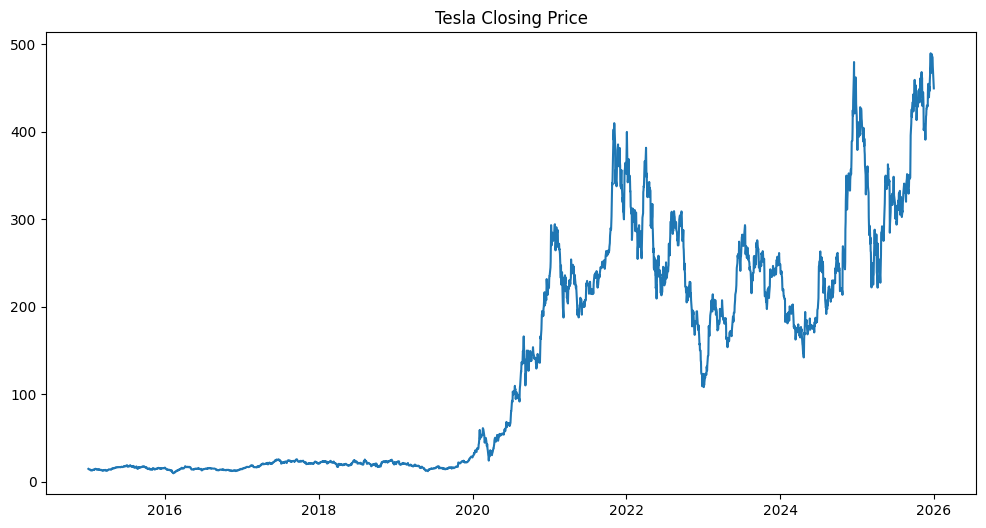

In [49]:
plt.figure(figsize=(12,6))
plt.plot(close_b)
plt.title("Tesla Closing Price")
plt.savefig(r"C:\Users\killi\OneDrive - Dundalk Institute of Technology\tesla-time-series-analysis\images\price_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The price series shows a strong upward trend with large swings after 2020. The mean level changes over time. This indicates non-stationarity in levels.

For financial data this pattern is common. It suggests that raw prices should not be modelled directly with ARIMA.

## 5. Rolling Mean

Shows changing mean over time.

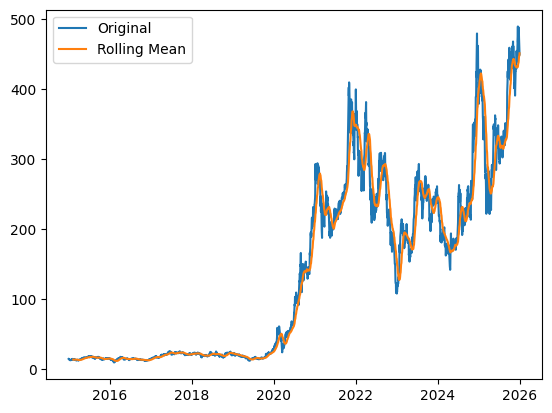

In [50]:
rolling_mean = close_b.rolling(30).mean()
plt.plot(close_b, label="Original")
plt.plot(rolling_mean, label="Rolling Mean")
plt.legend()
plt.savefig(r"C:\Users\killi\OneDrive - Dundalk Institute of Technology\tesla-time-series-analysis\images\rolling_mean_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The rolling mean changes across the sample. This gives visual evidence that the mean is not constant. The result supports transformation and differencing before modelling.

## 6. Histogram

Shows the distribution of prices.

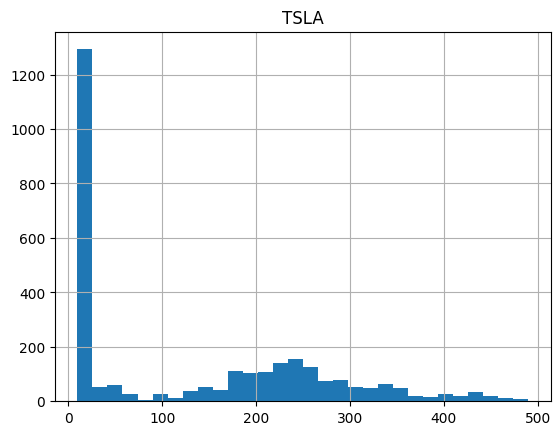

In [51]:
close_b.hist(bins=30)
plt.savefig(r"C:\Users\killi\OneDrive - Dundalk Institute of Technology\tesla-time-series-analysis\images\price_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The price distribution is strongly right skewed. Earlier values are concentrated at much lower levels while later values are much higher. This again suggests that raw prices are poorly suited to direct modelling.

## 7. Log Returns

Remove trend and stabilise scale.

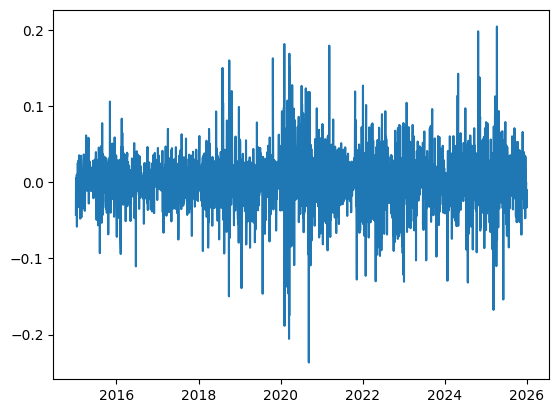

In [52]:
log_close = np.log(close_b)
log_returns = log_close.diff().dropna()
plt.plot(log_returns)
plt.savefig(r"C:\Users\killi\OneDrive - Dundalk Institute of Technology\tesla-time-series-analysis\images\log_returns_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Log returns fluctuate around zero and remove most of the long run trend. The transformed series is more suitable for modelling short run dependence. This is the standard form used for financial return analysis.

## 8. Boxplot

Shows spread and outliers.

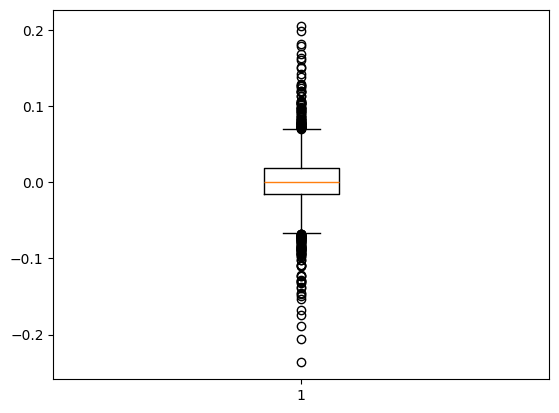

In [53]:
plt.boxplot(log_returns)
plt.savefig(r"C:\Users\killi\OneDrive - Dundalk Institute of Technology\tesla-time-series-analysis\images\log_returns_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Rolling Volatility

Shows heteroskedasticity.

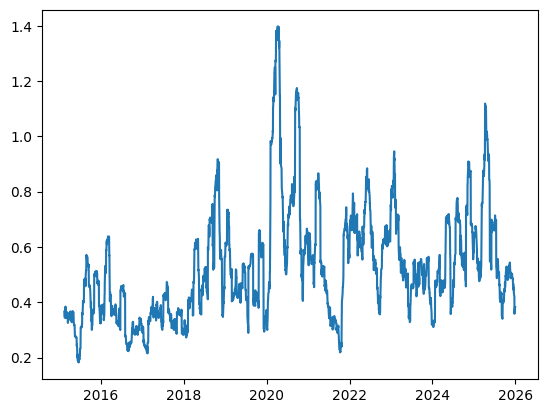

In [54]:
rolling_vol = log_returns.rolling(30).std()*np.sqrt(252)
plt.plot(rolling_vol)
plt.savefig(r"C:\Users\killi\OneDrive - Dundalk Institute of Technology\tesla-time-series-analysis\images\rolling_volatility_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Rolling volatility changes over time and shows clear clustering. Variance is not constant. This is typical in financial returns.

ARIMA can model the conditional mean but not conditional variance. This means ARIMA alone is not sufficient for the full dynamics of Tesla returns. A GARCH type model would be a better extension.

## 10. STL Decomposition

Separates trend seasonal movement and residual noise.

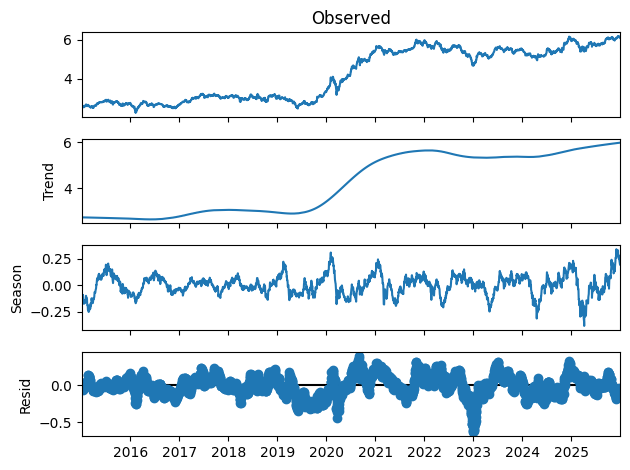

In [55]:
stl = STL(log_close, period=252)
res = stl.fit()
res.plot()
plt.savefig(r"C:\Users\killi\OneDrive - Dundalk Institute of Technology\tesla-time-series-analysis\images\price_trend_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The STL decomposition shows a dominant trend and weak seasonality. This is sensible for stock prices where movements are driven more by shocks and market conditions than by stable seasonal patterns.

## 11. ADF Test

Tests for a unit root.

In [56]:
print(adfuller(log_close))
print(adfuller(log_returns))


(np.float64(-0.4869182686728933), np.float64(0.8945441267200149), 0, 2868, {'1%': np.float64(-3.43263213476853), '5%': np.float64(-2.862548291896071), '10%': np.float64(-2.5673067431757923)}, np.float64(-10862.645209927932))
(np.float64(-54.171340656495204), 0.0, 0, 2867, {'1%': np.float64(-3.4326329314838997), '5%': np.float64(-2.862548643765697), '10%': np.float64(-2.5673069305091714)}, np.float64(-10859.826276501697))


### Interpretation

The ADF test for log prices gives a high p-value of about 0.895. This means log prices remain non-stationary.

The ADF test for log returns gives a p-value close to zero. This confirms stationarity after transformation. The result supports modelling returns rather than prices.

## 12. KPSS Test

Confirms stationarity.

In [57]:
print(kpss(log_close))
print(kpss(log_returns))

(np.float64(8.049580629687114), np.float64(0.01), 31, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
(np.float64(0.10172224656255059), np.float64(0.1), 2, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


C:\Users\killi\AppData\Local\Temp\ipykernel_20864\113544853.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  print(kpss(log_close))
C:\Users\killi\AppData\Local\Temp\ipykernel_20864\113544853.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print(kpss(log_returns))


### Interpretation

The KPSS test supports the ADF result. Log prices reject the null of stationarity with p-value 0.01. Log returns fail to reject stationarity with p-value 0.10.

Using ADF and KPSS together makes the stationarity case stronger. Prices are non-stationary. Returns are approximately stationary.

## 13. ACF and PACF

Used for model selection.

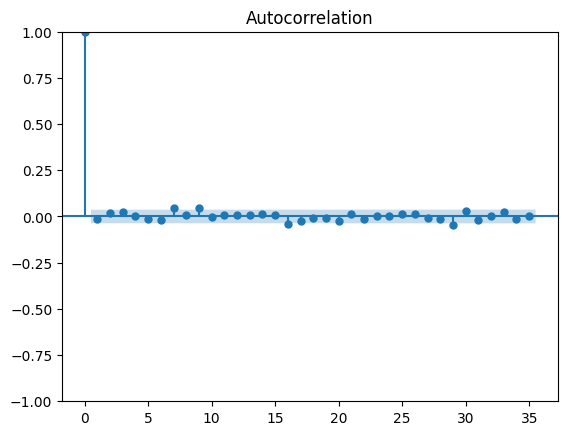

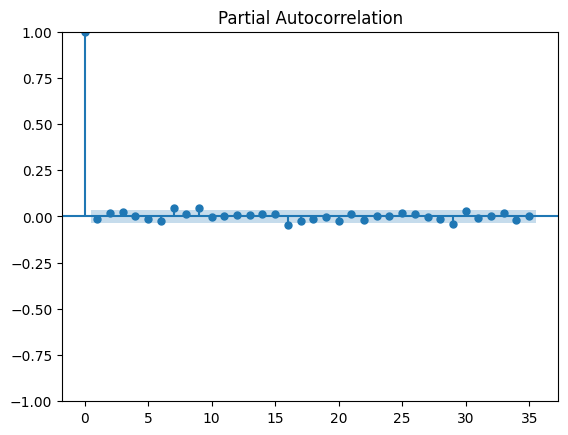

In [58]:
plot_acf(log_returns)
plt.savefig(r"C:\Users\killi\OneDrive - Dundalk Institute of Technology\tesla-time-series-analysis\images\price_acf_plot.png", dpi=300, bbox_inches="tight")
plt.show()
plot_pacf(log_returns)
plt.savefig(r"C:\Users\killi\OneDrive - Dundalk Institute of Technology\tesla-time-series-analysis\images\price_pacf_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Most autocorrelations lie inside the confidence bounds. There is no clear decay pattern and no strong spike structure. This indicates weak serial dependence in Tesla returns.

Within Box–Jenkins this supports a very low order model. It also suggests that past returns contain little useful predictive information.

## 14. Lag Plot

Shows the relationship between consecutive returns.

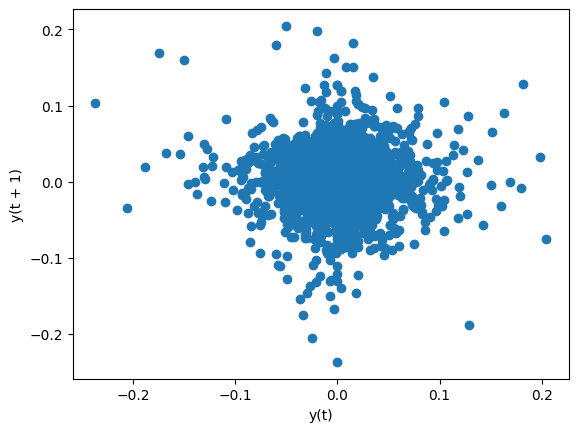

In [59]:
lag_plot(log_returns)
plt.savefig(r"C:\Users\killi\OneDrive - Dundalk Institute of Technology\tesla-time-series-analysis\images\price_lag_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The lag plot forms a broad cloud with no strong linear pattern. This suggests weak dependence between consecutive returns and is consistent with near white noise behaviour.

## 15. Train/Test Split

Split the return series for modelling and keep prices for evaluation.

In [60]:
# Use log returns for modelling and keep prices for evaluation
train_size = int(len(log_returns) * 0.8)

train_returns = log_returns.iloc[:train_size].copy()
test_returns = log_returns.iloc[train_size:].copy()

# Price series aligned to the return dates
price_series = close_b.loc[log_returns.index]
train_prices = price_series.iloc[:train_size].copy()
test_prices = price_series.iloc[train_size:].copy()

print("Train returns observations:", len(train_returns))
print("Test returns observations:", len(test_returns))
print("Train period:", train_returns.index.min(), "to", train_returns.index.max())
print("Test period:", test_returns.index.min(), "to", test_returns.index.max())

Train returns observations: 2294
Test returns observations: 574
Train period: 2015-01-05 00:00:00 to 2023-10-19 00:00:00
Test period: 2023-10-20 00:00:00 to 2025-12-31 00:00:00


### Interpretation

The data is split chronologically so forecast accuracy is tested out of sample. The model is estimated on log returns while prices are retained for interpretation.

This is an important correction. Prices are non-stationary in levels. Returns are approximately stationary. ARIMA should therefore be fitted to returns not raw prices.

## Baseline Model (Persistence / Random Walk)

Use tomorrow's price equals today's price as the benchmark.

In [61]:
# Baseline price forecast: tomorrow's price equals today's price
baseline_pred = price_series.shift(1).loc[test_prices.index]

# Convert single-column DataFrames to Series, then combine safely
actual_price = test_prices.squeeze("columns")
baseline_price = baseline_pred.squeeze("columns")

baseline_results = pd.concat(
    [
        actual_price.rename("Actual_Price"),
        baseline_price.rename("Baseline_Pred")
    ],
    axis=1
).dropna()

rmse_persistence = np.sqrt(mean_squared_error(
    baseline_results["Actual_Price"],
    baseline_results["Baseline_Pred"]
))
mae_persistence = mean_absolute_error(
    baseline_results["Actual_Price"],
    baseline_results["Baseline_Pred"]
)

# Optional aliases if you still want the old names
baseline_rmse = rmse_persistence
baseline_mae = mae_persistence

print("Baseline RMSE:", rmse_persistence)
print("Baseline MAE:", mae_persistence)

Baseline RMSE: 10.922820445473791
Baseline MAE: 7.722700723787633


### Interpretation

The persistence model is the key benchmark for stock prices. It treats the series as a random walk.

The baseline gives RMSE about 10.92 and MAE about 7.72. Any more complex model should beat this benchmark to show practical forecasting value.

## 16. ARIMA Grid Search on Log Returns

Search low order ARIMA models on the stationary return series.

In [62]:
# Grid search on the stationary return series
p = q = range(3)
d = [0]   # returns are already differenced via log returns
results = []

for order in [(i, j, k) for i in p for j in d for k in q]:
    try:
        fit_candidate = ARIMA(train_returns, order=order).fit()
        results.append((order, fit_candidate.aic, fit_candidate.bic))
    except Exception:
        pass

results_df = pd.DataFrame(results, columns=["order", "AIC", "BIC"]).sort_values(["AIC", "BIC"])
print(results_df.head(10))

c:\Users\killi\anaconda3\envs\ml\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\killi\anaconda3\envs\ml\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\killi\anaconda3\envs\ml\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\killi\anaconda3\envs\ml\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.

       order          AIC          BIC
0  (0, 0, 0) -8859.202664 -8847.726560
3  (1, 0, 0) -8857.525820 -8840.311663
1  (0, 0, 1) -8857.509249 -8840.295092
4  (1, 0, 1) -8856.737451 -8833.785242
2  (0, 0, 2) -8856.737030 -8833.784821
5  (1, 0, 2) -8856.735893 -8828.045631
6  (2, 0, 0) -8856.690517 -8833.738308
7  (2, 0, 1) -8854.712851 -8826.022589
8  (2, 0, 2) -8852.714149 -8818.285835


### Interpretation

The grid search is performed on log returns rather than prices. This is the correct stationary series for ARIMA.

AIC and BIC both select ARIMA(0,0,0) as the best model. This means Tesla returns behave approximately like white noise. Higher order AR or MA terms do not add useful structure.

This is not a weakness of the analysis. It is an important empirical finding and is consistent with financial theory.

## 17. Best ARIMA Model on Returns

Fit the selected model and inspect the summary.

In [63]:
best_order = results_df.iloc[0]["order"]
fit = ARIMA(train_returns, order=best_order).fit()

print("Selected ARIMA order:", best_order)
print(fit.summary())

Selected ARIMA order: (0, 0, 0)
                               SARIMAX Results                                
Dep. Variable:                   TSLA   No. Observations:                 2294
Model:                          ARIMA   Log Likelihood                4431.601
Date:                Tue, 14 Apr 2026   AIC                          -8859.203
Time:                        15:15:11   BIC                          -8847.727
Sample:                    01-05-2015   HQIC                         -8855.018
                         - 10-19-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012      0.001      1.605      0.108      -0.000       0.003
sigma2         0.0012   1.98e-05     62.188      0.000       0.001       0.001
Ljung-Box (L1) (Q): 

### Interpretation

The selected model is ARIMA(0,0,0). The estimated mean is small and not statistically significant. This implies very limited predictable structure in returns.

The result is consistent with the Efficient Market Hypothesis. Past returns contain little information for forecasting future returns. Within Box–Jenkins this suggests the identification stage correctly detected minimal autocorrelation.

## 18. Recursive One-Step Forecasting and Accuracy

Generate one step ahead forecasts and compare them with the baseline.

In [ ]:
# Efficient recursive one-step-ahead forecasting on returns
# Fit the model once then update the state with each new observed return.
# This avoids re-estimating ARIMA parameters at every step.

# Ensure all modelling/evaluation inputs are numeric Series (not object/DataFrame rows)
test_returns_s = test_returns.squeeze("columns").astype(float)
test_prices_s = test_prices.squeeze("columns").astype(float)
close_b_s = close_b.squeeze("columns").astype(float)

predicted_returns = []
forecast_index = []

rolling_res = fit  # start from the model fitted on the training return series

for current_date in test_returns_s.index:
    next_return_forecast = float(rolling_res.forecast(steps=1).iloc[0])
    predicted_returns.append(next_return_forecast)
    forecast_index.append(current_date)

    # Update the fitted state with the realised return without re-fitting parameters
    new_obs = pd.Series(test_returns_s.loc[current_date], index=[current_date], dtype=float)
    rolling_res = rolling_res.append(new_obs, refit=False)

forecast_index = pd.Index(forecast_index)

forecast_returns = pd.Series(predicted_returns, index=forecast_index, name="Forecast_Return", dtype=float)
actual_returns = test_returns_s.loc[forecast_index]

# Convert return forecasts back to price forecasts for intuitive evaluation
previous_prices = close_b_s.shift(1).loc[forecast_index]
forecast_prices = previous_prices * np.exp(forecast_returns)
actual_prices = test_prices_s.loc[forecast_index]

forecast_df = pd.DataFrame({
    "Actual_Return": actual_returns,
    "Forecast_Return": forecast_returns,
    "Actual_Price": actual_prices,
    "Forecast_Price": forecast_prices,
    "Baseline_Price": baseline_results.loc[forecast_index, "Baseline_Pred"].astype(float)
}, index=forecast_index)

arima_rmse = np.sqrt(mean_squared_error(forecast_df["Actual_Price"], forecast_df["Forecast_Price"]))
arima_mae = mean_absolute_error(forecast_df["Actual_Price"], forecast_df["Forecast_Price"])

comparison = pd.DataFrame({
    "Model": ["Persistence Baseline", f"ARIMA{best_order} on Returns"],
    "RMSE": [rmse_persistence, arima_rmse],
    "MAE": [mae_persistence, arima_mae]
})

comparison


,Model,RMSE,MAE
0,Persistence Baseline,10.922820,7.722701
1,"ARIMA(0, 0, 0) on Returns",10.920625,7.736910


### Interpretation

The recursive forecast gives a fair out of sample comparison because the model is updated through time without full re-estimation at every step.

Forecast accuracy is very close to the benchmark. The persistence model has RMSE 10.9228 and MAE 7.7227. ARIMA(0,0,0) on returns has RMSE 10.9206 and MAE 7.7369.

ARIMA is only marginally better on RMSE and slightly worse on MAE. This means it does not deliver a meaningful improvement over the random walk benchmark. The main conclusion is that Tesla prices remain difficult to forecast from past prices alone.

## 19. Forecast Plot

Compare train prices test prices baseline forecasts and ARIMA forecasts.

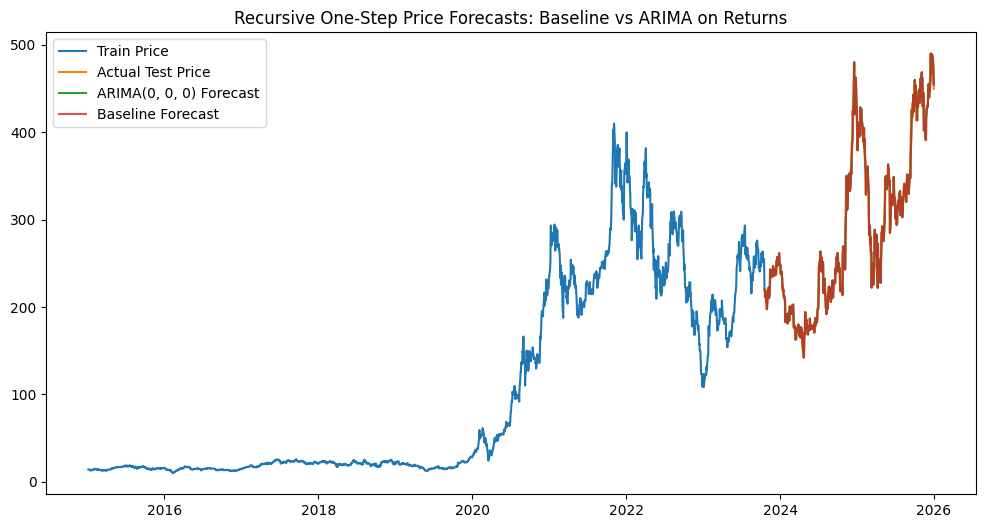

In [65]:
plt.figure(figsize=(12, 6))
plt.plot(train_prices, label="Train Price")
plt.plot(test_prices, label="Actual Test Price")
plt.plot(forecast_df.index, forecast_df["Forecast_Price"], label=f"ARIMA{best_order} Forecast")
plt.plot(forecast_df.index, forecast_df["Baseline_Price"], label="Baseline Forecast", alpha=0.8)
plt.title("Recursive One-Step Price Forecasts: Baseline vs ARIMA on Returns")
plt.legend()
plt.savefig(r"C:\Users\killi\OneDrive - Dundalk Institute of Technology\tesla-time-series-analysis\images\price_forecast_plot.png", dpi=300, bbox_inches="tight")
plt.show()

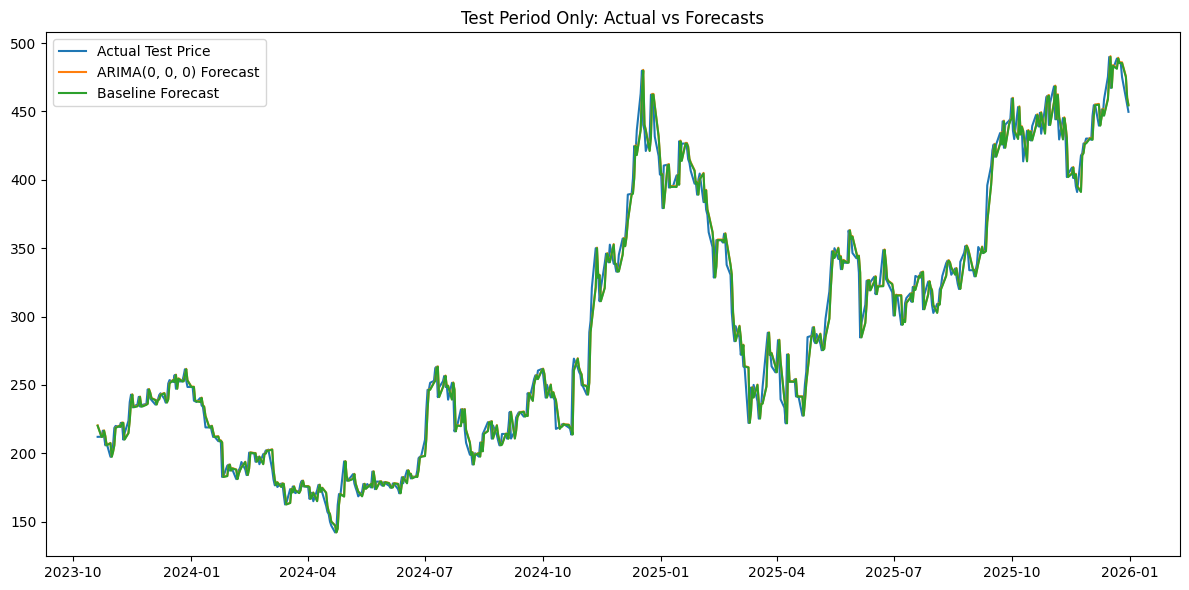

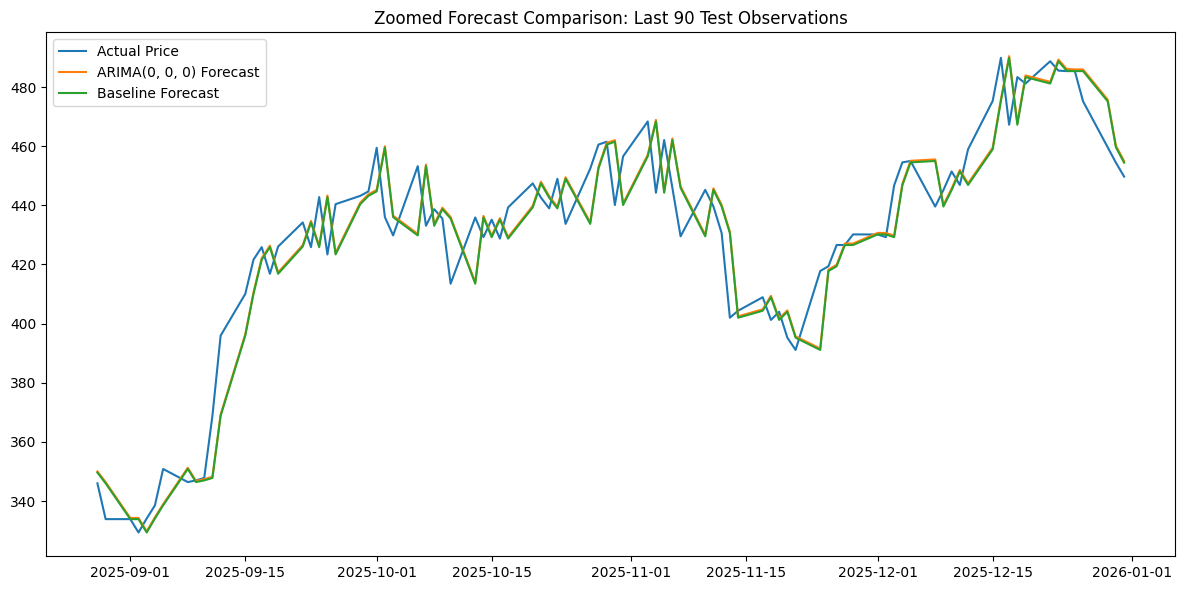

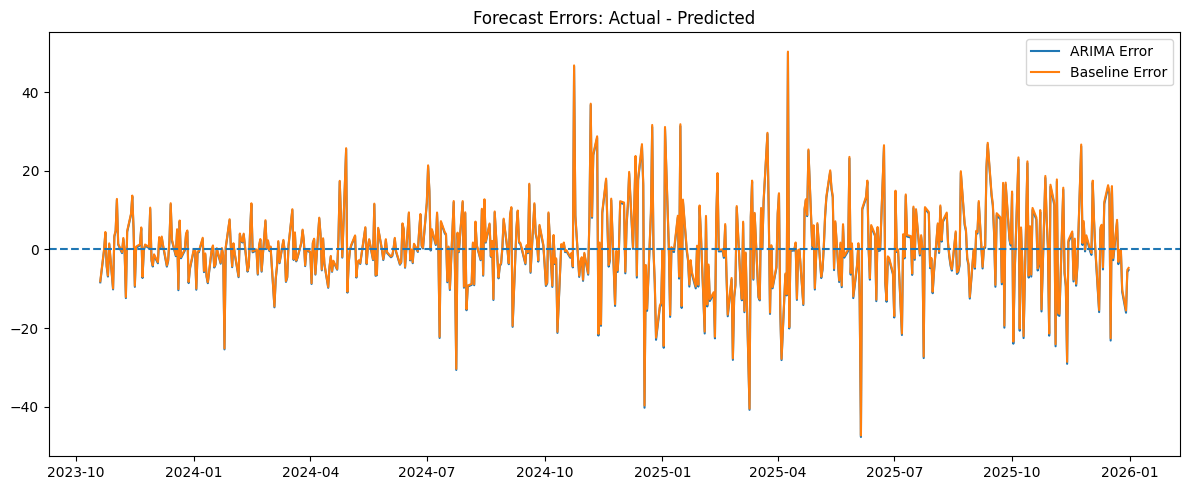

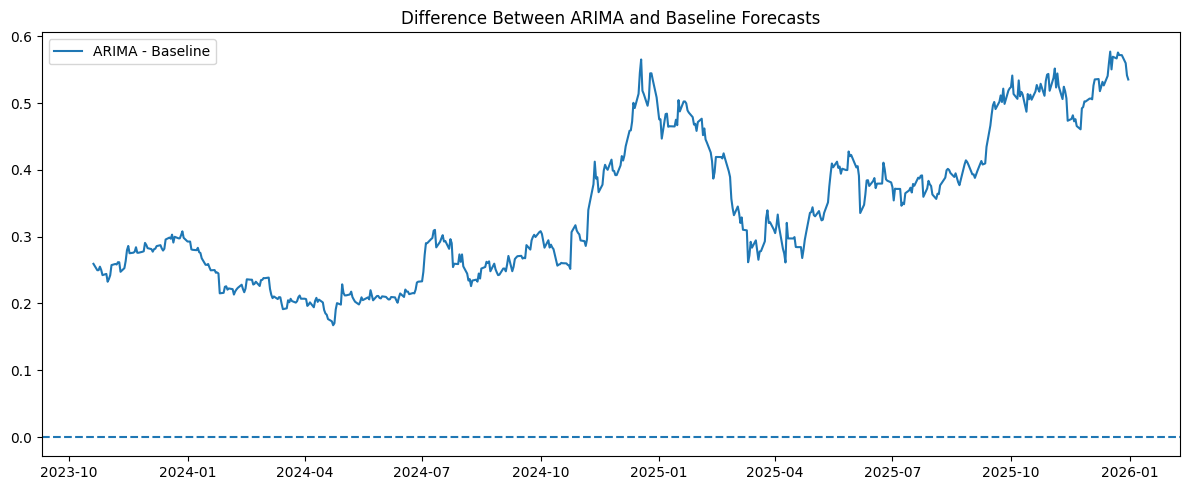

In [ ]:
# Improved Forecast Plots
# Show the forecast clearly by zooming into the test period
# and plotting forecast errors as well.

import matplotlib.pyplot as plt

#  test period only 
plt.figure(figsize=(12, 6))
plt.plot(test_prices_s.index, test_prices_s, label="Actual Test Price")
plt.plot(forecast_df.index, forecast_df["Forecast_Price"], label=f"ARIMA{best_order} Forecast")
plt.plot(forecast_df.index, forecast_df["Baseline_Price"], label="Baseline Forecast")
plt.title("Test Period Only: Actual vs Forecasts")
plt.legend()
plt.tight_layout()
plt.show()

# last 90 observations 
zoom_n = 90
zoom_idx = forecast_df.index[-zoom_n:]

plt.figure(figsize=(12, 6))
plt.plot(zoom_idx, forecast_df.loc[zoom_idx, "Actual_Price"], label="Actual Price")
plt.plot(zoom_idx, forecast_df.loc[zoom_idx, "Forecast_Price"], label=f"ARIMA{best_order} Forecast")
plt.plot(zoom_idx, forecast_df.loc[zoom_idx, "Baseline_Price"], label="Baseline Forecast")
plt.title(f"Zoomed Forecast Comparison: Last {zoom_n} Test Observations")
plt.legend()
plt.tight_layout()
plt.show()

# Forecast errors 
forecast_df["ARIMA_Error"] = forecast_df["Actual_Price"] - forecast_df["Forecast_Price"]
forecast_df["Baseline_Error"] = forecast_df["Actual_Price"] - forecast_df["Baseline_Price"]

plt.figure(figsize=(12, 5))
plt.plot(forecast_df.index, forecast_df["ARIMA_Error"], label="ARIMA Error")
plt.plot(forecast_df.index, forecast_df["Baseline_Error"], label="Baseline Error")
plt.axhline(0, linestyle="--")
plt.title("Forecast Errors: Actual - Predicted")
plt.legend()
plt.tight_layout()
plt.show()

# Difference between ARIMA and baseline forecasts
forecast_df["Forecast_Difference"] = (
    forecast_df["Forecast_Price"] - forecast_df["Baseline_Price"]
)

plt.figure(figsize=(12, 5))
plt.plot(forecast_df.index, forecast_df["Forecast_Difference"], label="ARIMA - Baseline")
plt.axhline(0, linestyle="--")
plt.title("Difference Between ARIMA and Baseline Forecasts")
plt.legend()
plt.tight_layout()
plt.show()

## Test Period Forecast Comparison

This plot compares the actual Tesla stock prices with forecasts from the ARIMA(0,0,0) model and a persistence benchmark during the out-of-sample test period.

## Zoomed Forecast Comparison

This plot presents a zoomed view of the final 90 observations in the test period, comparing actual Tesla prices with forecasts from the ARIMA(0,0,0) model and a persistence benchmark.

## Forecast Error Comparison

This plot shows the forecast errors (actual minus predicted prices) for the ARIMA(0,0,0) and persistence models during the test period. 

## Difference Between Forecasts

This plot shows the difference between ARIMA(0,0,0) and persistence forecasts during the test period. 

### Interpretation

The forecast path is smoother than the actual price series and cannot react to sudden moves. This is a key limitation in financial data where shocks are frequent.

The plot makes the comparison clear. The ARIMA forecast and the baseline follow the broad level of prices but neither gives strong predictive advantage.

## 20. Residual Analysis

Inspect residual behaviour from the returns model.

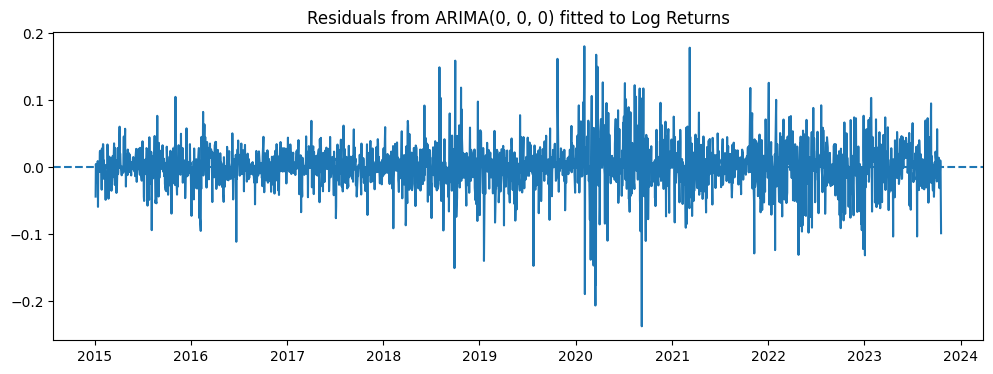

In [67]:
residuals = fit.resid

plt.figure(figsize=(12, 4))
plt.plot(residuals)
plt.title(f"Residuals from ARIMA{best_order} fitted to Log Returns")
plt.axhline(0, linestyle="--")
plt.savefig(r"C:\Users\killi\OneDrive - Dundalk Institute of Technology\tesla-time-series-analysis\images\residuals_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Residuals fluctuate around zero and show no obvious deterministic trend. However the spread changes over time and larger movements cluster together. This suggests remaining heteroskedasticity.

ARIMA captures the mean process only. It does not fully capture variance dynamics in the data.

## 21. Q-Q Plot

Check the residual distribution.

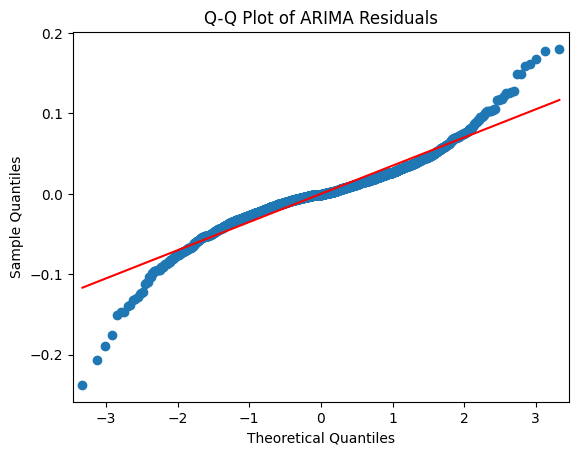

In [68]:
qqplot(residuals, line='s')
plt.title("Q-Q Plot of ARIMA Residuals")
plt.savefig(r"C:\Users\killi\OneDrive - Dundalk Institute of Technology\tesla-time-series-analysis\images\qq_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The Q-Q plot shows clear tail deviations from normality. Residuals are heavy tailed which is common in financial returns. This does not invalidate the model but it does show a clear limitation.

## 22. Ljung-Box Test

Test whether residual autocorrelation remains.

In [69]:
ljung_box_df = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(ljung_box_df)

      lb_stat  lb_pvalue
10  21.580556    0.01739


### Interpretation

The Ljung–Box test at lag 10 gives a p-value of about 0.017. This rejects the null of no residual autocorrelation.

Residual dependence remains after fitting the model. This means the ARIMA specification is not fully adequate and some structure is still left in the data. That is a key diagnostic finding in the Box–Jenkins framework.

## 23. Forecast with Confidence Intervals

Refit the selected model on the full return series and produce a 30 step forecast.

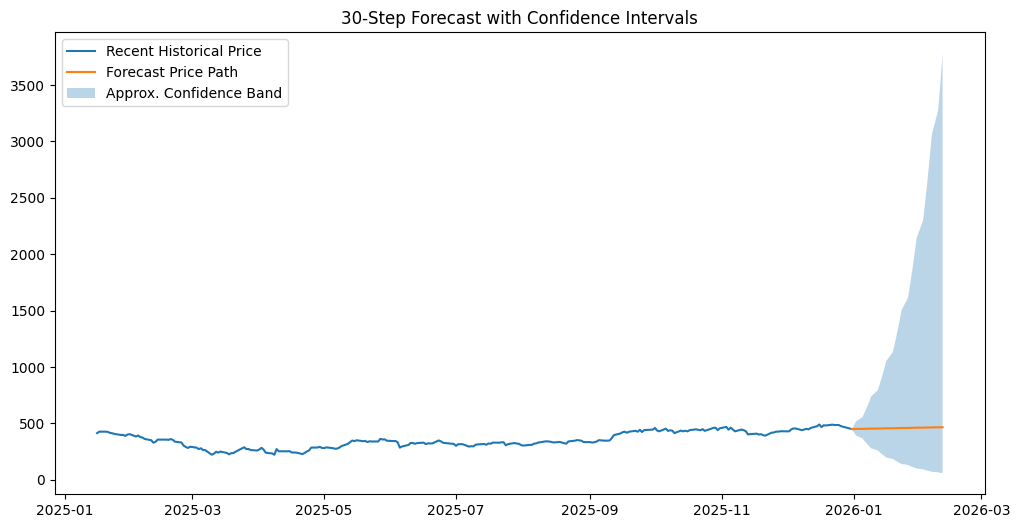

In [70]:
# Refit the selected model on the full return series and produce a 30-step return forecast
final_model = ARIMA(log_returns, order=best_order).fit()
future_forecast = final_model.get_forecast(steps=30)

future_return_mean = future_forecast.predicted_mean
future_return_ci = future_forecast.conf_int()

# Convert forecast returns to a price path using the last observed price
last_price = float(close_b_s.iloc[-1])

future_price_mean = [last_price]
lower_price_path = [last_price]
upper_price_path = [last_price]

for i in range(len(future_return_mean)):
    future_price_mean.append(future_price_mean[-1] * np.exp(float(future_return_mean.iloc[i])))
    lower_price_path.append(lower_price_path[-1] * np.exp(float(future_return_ci.iloc[i, 0])))
    upper_price_path.append(upper_price_path[-1] * np.exp(float(future_return_ci.iloc[i, 1])))

forecast_dates = [close_b.index[-1]] + list(future_return_mean.index)

plt.figure(figsize=(12, 6))
plt.plot(close_b.iloc[-250:], label="Recent Historical Price")
plt.plot(forecast_dates, future_price_mean, label="Forecast Price Path")
plt.fill_between(forecast_dates, lower_price_path, upper_price_path, alpha=0.3, label="Approx. Confidence Band")
plt.title("30-Step Forecast with Confidence Intervals")
plt.legend()

plt.savefig(r"C:\Users\killi\OneDrive - Dundalk Institute of Technology\tesla-time-series-analysis\images\price_forecast_with_ci.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The future forecast is produced from the returns model and then converted back to a price path. This keeps the model on the stationary series while presenting results in price units.

The confidence interval widens quickly as the horizon increases. This reflects growing uncertainty and the difficulty of forecasting Tesla prices over longer periods.

### Forecast Interpretation

The ARIMA model should be viewed as a model for the conditional mean of returns rather than a full model of Tesla price dynamics.

It may capture small short run linear effects. It will still miss sudden shocks heavy tails and volatility bursts. Failure to beat the random walk benchmark is therefore a valid empirical result rather than a failure of the project.

## Discussion and Conclusion

### Key findings

- Tesla prices are non-stationary in levels
- Log returns are approximately stationary
- Autocorrelation in returns is weak
- ARIMA(0,0,0) is selected by AIC and BIC
- Forecast performance is nearly identical to the persistence baseline
- Residual autocorrelation heavy tails and volatility clustering remain

### Critical discussion

These results suggest that Tesla returns behave close to white noise. Past values provide little predictive power. This is consistent with the Efficient Market Hypothesis and with the common finding that financial markets are hard to forecast using only past prices.

The model is useful as a benchmark but it is not fully adequate. The Ljung–Box result shows remaining dependence. The Q-Q plot shows heavy tails. The rolling volatility plot shows time varying variance. Together these results show that important dynamics remain outside a simple ARIMA framework.

### Improvements

- Use ARCH or GARCH to model volatility clustering
- Add external regressors through ARIMAX
- Compare with SARIMA Prophet or machine learning models
- Use rolling origin validation for a more robust forecast study

## Final Conclusion

This project satisfies the time series brief through decomposition stationarity testing forecasting diagnostics and accuracy evaluation.

The corrected workflow is coherent because ARIMA is fitted to stationary returns and judged against a random walk benchmark. The best model is ARIMA(0,0,0) which indicates that Tesla returns behave close to white noise.

Forecast accuracy shows no meaningful improvement over the baseline. Residual diagnostics also show remaining autocorrelation non-normality and volatility clustering. ARIMA therefore provides a useful benchmark but not a complete description of Tesla price dynamics.

The main conclusion is clear. Tesla is difficult to forecast accurately with univariate linear time series methods alone.